#  QUADRATIC SPLINE


S_0(x) = 0.0000x^2 + 1.0000x + 1.0000, for 0 ≤ x ≤ 1
S_1(x) = 30.0000x^2 + -59.0000x + 31.0000, for 1 ≤ x ≤ 2
S_2(x) = 150.0000x^2 + -539.0000x + 511.0000, for 2 ≤ x ≤ 3
Interpolated value at x = 2.5: 101.0000


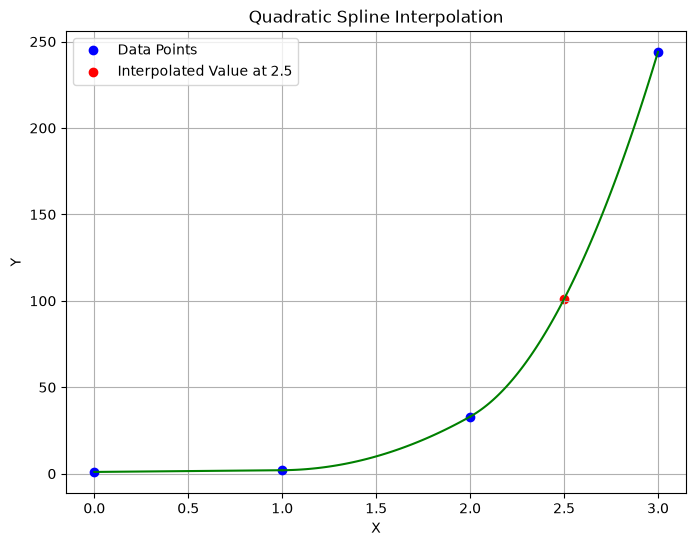

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def quadratic_spline(x, y, xp):
    n = len(x) - 1
    A = np.zeros((3 * n, 3 * n))
    b = np.zeros(3 * n)

    equations = []

    # Setting up equations for spline segments
    row = 0
    for i in range(n):
        A[row, 3*i] = x[i]**2
        A[row, 3*i + 1] = x[i]
        A[row, 3*i + 2] = 1
        b[row] = y[i]
        row += 1

        A[row, 3*i] = x[i+1]**2
        A[row, 3*i + 1] = x[i+1]
        A[row, 3*i + 2] = 1
        b[row] = y[i+1]
        row += 1

    # Continuity condition (first derivatives match at internal points)
    for i in range(n - 1):
        A[row, 3*i] = 2 * x[i+1]
        A[row, 3*i + 1] = 1
        A[row, 3*i + 3] = -2 * x[i+1]
        A[row, 3*i + 4] = -1
        row += 1

    # Natural spline condition (second derivative at the first and last points is zero)
    A[row, 0] = 2
    row += 1
    # A[row, 3*(n-1) + 2] = 2  # Corrected index to avoid out-of-bounds error
    # row += 1

    coeffs = np.linalg.solve(A, b)

    # Constructing spline equations
    for i in range(n):
        a, b, c = coeffs[3*i:3*i + 3]
        eq = f"S_{i}(x) = {a:.4f}x^2 + {b:.4f}x + {c:.4f}, for {x[i]} ≤ x ≤ {x[i+1]}"
        equations.append(eq)
        print(eq)

    # Finding interpolated value
    y_interp = None
    for i in range(n):
        if x[i] <= xp <= x[i+1]:
            y_interp = coeffs[3*i] * xp**2 + coeffs[3*i + 1] * xp + coeffs[3*i + 2]
            break

    return equations, y_interp, coeffs


# Example Data Points
#x_points = np.array([1, 2, 3, 4, 5])
#y_points = np.array([2, 3, 5, 7, 11])
x_points = np.array([0, 1, 2, 3])
y_points = np.array([1, 2, 33, 244])


# Interpolation Point
x_interp = 2.5
splines, y_interp, coeffs = quadratic_spline(x_points, y_points, x_interp)
print(f"Interpolated value at x = {x_interp}: {y_interp:.4f}")

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(x_points, y_points, 'bo', label='Data Points')
plt.scatter(x_interp, y_interp, color='red', label=f'Interpolated Value at {x_interp}')

# Plot quadratic spline segments
for i in range(len(x_points) - 1):
    x_vals = np.linspace(x_points[i], x_points[i + 1], 100)
    y_vals = (coeffs[3*i] * x_vals**2 + coeffs[3*i + 1] * x_vals + coeffs[3*i + 2])
    plt.plot(x_vals, y_vals, 'g-')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Quadratic Spline Interpolation')
plt.legend()
plt.grid(True)
plt.show()

# CUBIC SPLINE

S_0(x) = -4.0000x^3 + 0.0000x^2 + 5.0000x + 1.0000, for 0 ≤ x ≤ 1
S_1(x) = 50.0000x^3 + -162.0000x^2 + 167.0000x + -53.0000, for 1 ≤ x ≤ 2
S_2(x) = -46.0000x^3 + 414.0000x^2 + -985.0000x + 715.0000, for 2 ≤ x ≤ 3
Interpolated value at x = 1.5: 1.7500


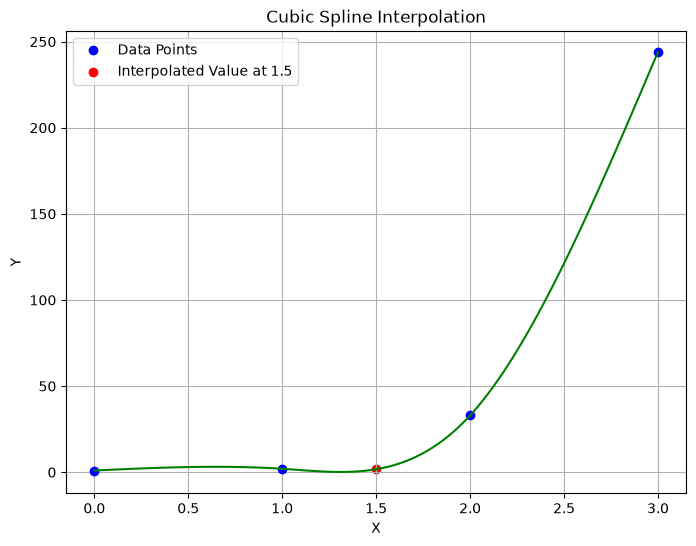

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def cubic_spline(x, y, xp):
    n = len(x) - 1
    h = np.diff(x)

    # Construct the system of equations
    A = np.zeros((4 * n, 4 * n))
    b = np.zeros(4 * n)

    row = 0
    equations = []

    # Spline equations at each interval endpoint
    for i in range(n):
        A[row, 4*i] = x[i]**3
        A[row, 4*i + 1] = x[i]**2
        A[row, 4*i + 2] = x[i]
        A[row, 4*i + 3] = 1
        b[row] = y[i]
        row += 1

        A[row, 4*i] = x[i+1]**3
        A[row, 4*i + 1] = x[i+1]**2
        A[row, 4*i + 2] = x[i+1]
        A[row, 4*i + 3] = 1
        b[row] = y[i+1]
        row += 1

    # First derivative continuity
    for i in range(n - 1):
        A[row, 4*i] = 3 * x[i+1]**2
        A[row, 4*i + 1] = 2 * x[i+1]
        A[row, 4*i + 2] = 1
        A[row, 4*i + 4] = -3 * x[i+1]**2
        A[row, 4*i + 5] = -2 * x[i+1]
        A[row, 4*i + 6] = -1
        row += 1

    # Second derivative continuity
    for i in range(n - 1):
        A[row, 4*i] = 6 * x[i+1]
        A[row, 4*i + 1] = 2
        A[row, 4*i + 4] = -6 * x[i+1]
        A[row, 4*i + 5] = -2
        row += 1

    # Natural spline conditions (second derivative at endpoints = 0)
    A[row, 0] = 6 * x[0]
    A[row, 1] = 2
    row += 1

    A[row, -4] = 6 * x[-1]
    A[row, -3] = 2

    coeffs = np.linalg.solve(A, b)

    # Constructing spline equations
    for i in range(n):
        a, b, c, d = coeffs[4*i:4*i + 4]
        eq = f"S_{i}(x) = {a:.4f}x^3 + {b:.4f}x^2 + {c:.4f}x + {d:.4f}, for {x[i]} ≤ x ≤ {x[i+1]}"
        equations.append(eq)
        print(eq)

    # Finding interpolated value
    y_interp = None
    for i in range(n):
        if x[i] <= xp <= x[i+1]:
            y_interp = coeffs[4*i] * xp**3 + coeffs[4*i + 1] * xp**2 + coeffs[4*i + 2] * xp + coeffs[4*i + 3]
            break

    return equations, y_interp, coeffs


# Example Data Points
#x_points = np.array([0, 1, 2, 3, 4])
#y_points = np.array([1, 2, 0, 2, 3])
x_points = np.array([0, 1, 2, 3])
y_points = np.array([1, 2, 33, 244])


# Interpolation Point
x_interp = 1.5
splines, y_interp, coeffs = cubic_spline(x_points, y_points, x_interp)
print(f"Interpolated value at x = {x_interp}: {y_interp:.4f}")


# Plotting
plt.figure(figsize=(8, 6))
plt.plot(x_points, y_points, 'bo', label='Data Points')
plt.scatter(x_interp, y_interp, color='red', label=f'Interpolated Value at {x_interp}')

# Plot cubic spline segments
for i in range(len(x_points) - 1):
    x_vals = np.linspace(x_points[i], x_points[i + 1], 100)
    y_vals = (coeffs[4*i] * x_vals**3 + coeffs[4*i + 1] * x_vals**2 + coeffs[4*i + 2] * x_vals + coeffs[4*i + 3])
    plt.plot(x_vals, y_vals, 'g-')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Cubic Spline Interpolation')
plt.legend()
plt.grid(True)
plt.show()